In [1]:
%cd ../../

/Users/paulb/Desktop/code/research/babi


In [2]:
import os
import pandas as pd
from data import constants, plotting
import numpy as np

{'Patient ID': 'BB_003_1', 'Patient Type': 'Infant/Neonatal', 'Report Generation Time': 'Mar 10,25  08:12:56 AM', 'Date': 'Mar 10,25'}
40405 samples (2020.25 seconds)


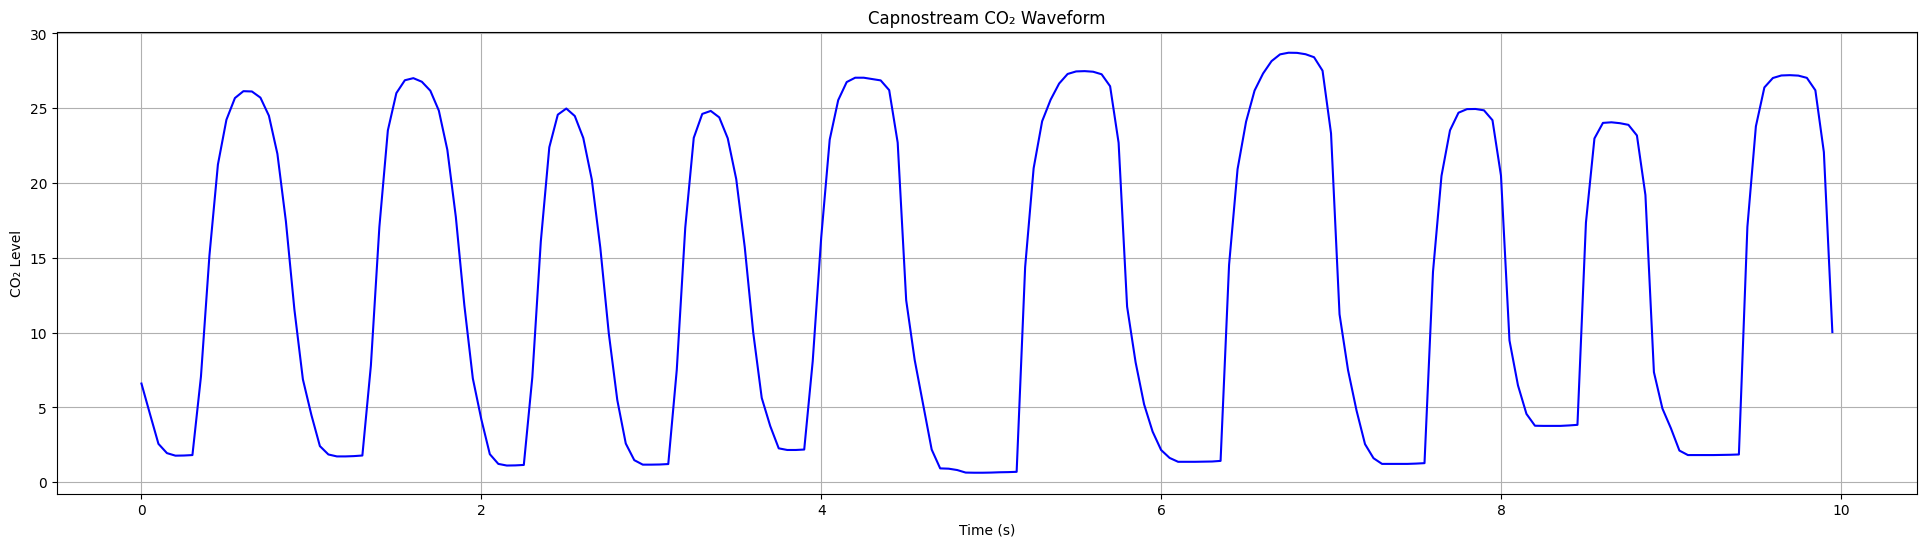

In [3]:
first_preprocessed_capnostream_file = os.listdir(os.path.join(constants.preprocessed_data_dir, "capnostream"))[1]
capnostream_file_df: pd.DataFrame = pd.read_pickle(os.path.join(constants.preprocessed_data_dir, "capnostream", first_preprocessed_capnostream_file))
signal = capnostream_file_df["co2_wave"].to_numpy()
print(capnostream_file_df.attrs) # show metadata
print(f"{len(signal)} samples ({len(signal) / constants.capnostream_sampling_rate:.2f} seconds)")
plotting.plot_capnostream_waveform(data=capnostream_file_df["co2_wave"][:200])

Constraint 'min_amplitude' failures: 92044
Constraint 'plateau_slope_tolerance' failures: 122982
Constraint 'plateau_vertical_tolerance' failures: 3377
Constraint 'min_length' failures: 8640
Constraint 'max_units_from_zero' failures: 478
Constraint 'unit_max_amplitude' failures: 4825
Constraint 'mean_max_amplitude_error_percentage' failures: 33
Min unit length: 0.55 seconds.
Max unit length: 1.50 seconds.
Mean unit length: 1.12 seconds.
Total unit length: 33.34 minutes.
Extracted 1778 units for training dataset.


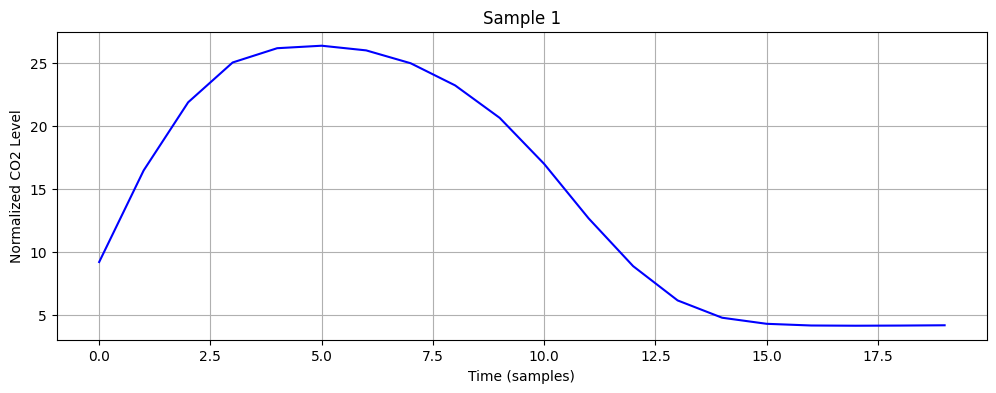

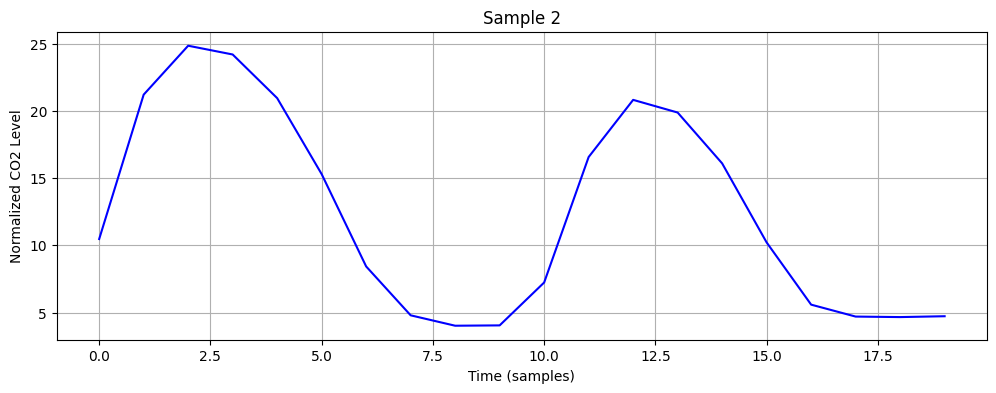

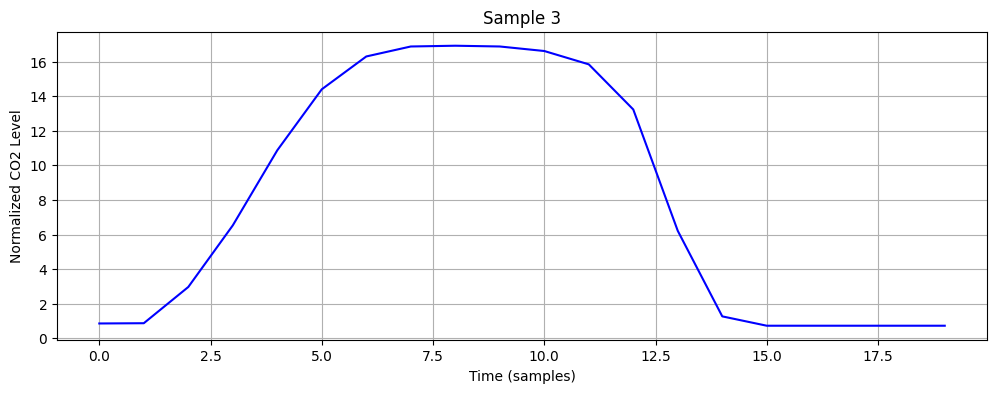

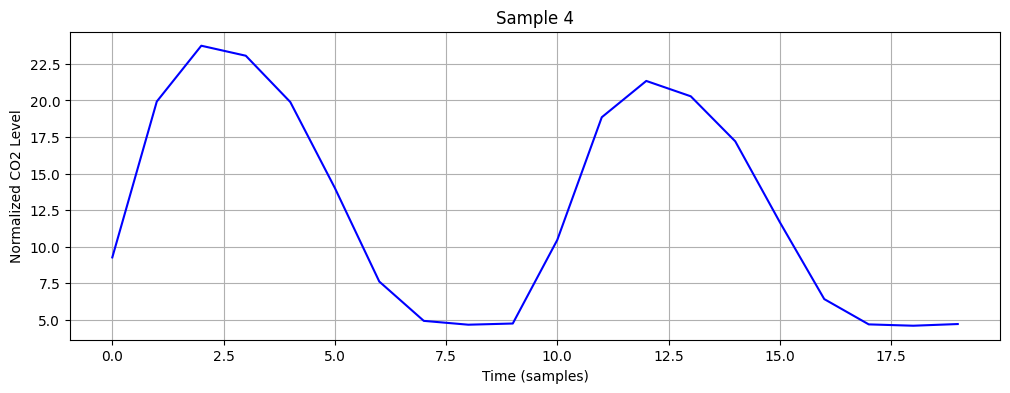

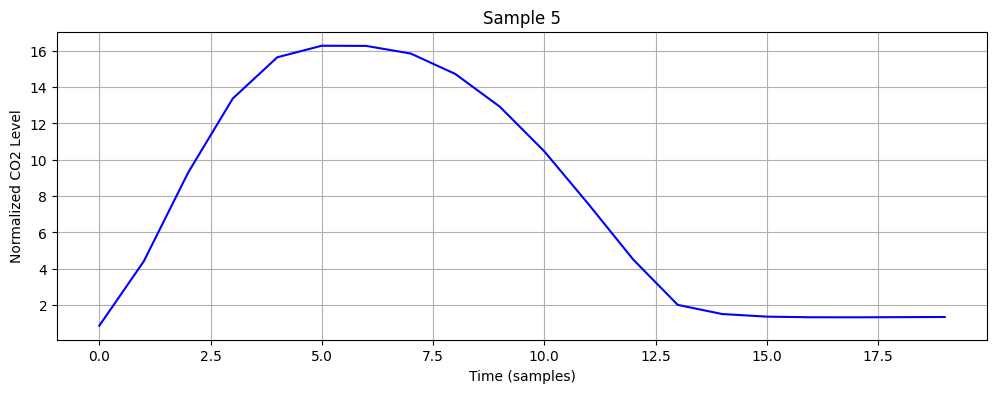

In [ ]:
from models import processing # /// stupid pathing...
import matplotlib.pyplot as plt

training_set, (set_mean, set_std) = processing.get_training_dataset(unit_length=20)

# generate out folder of images for pruning
for (i, sample) in enumerate(training_set):
    plt.figure(figsize=(12, 4))
    plt.plot(sample, color='blue')
    plt.title(f"Sample {i+1}")
    plt.xlabel("Time (samples)")
    plt.ylabel("Normalized CO2 Level")
    plt.grid()
    plt.savefig(f"data/prepare/out/{i+1}.png")
    plt.close()

Extracted 721 unit signals.
Augmentation type: raw


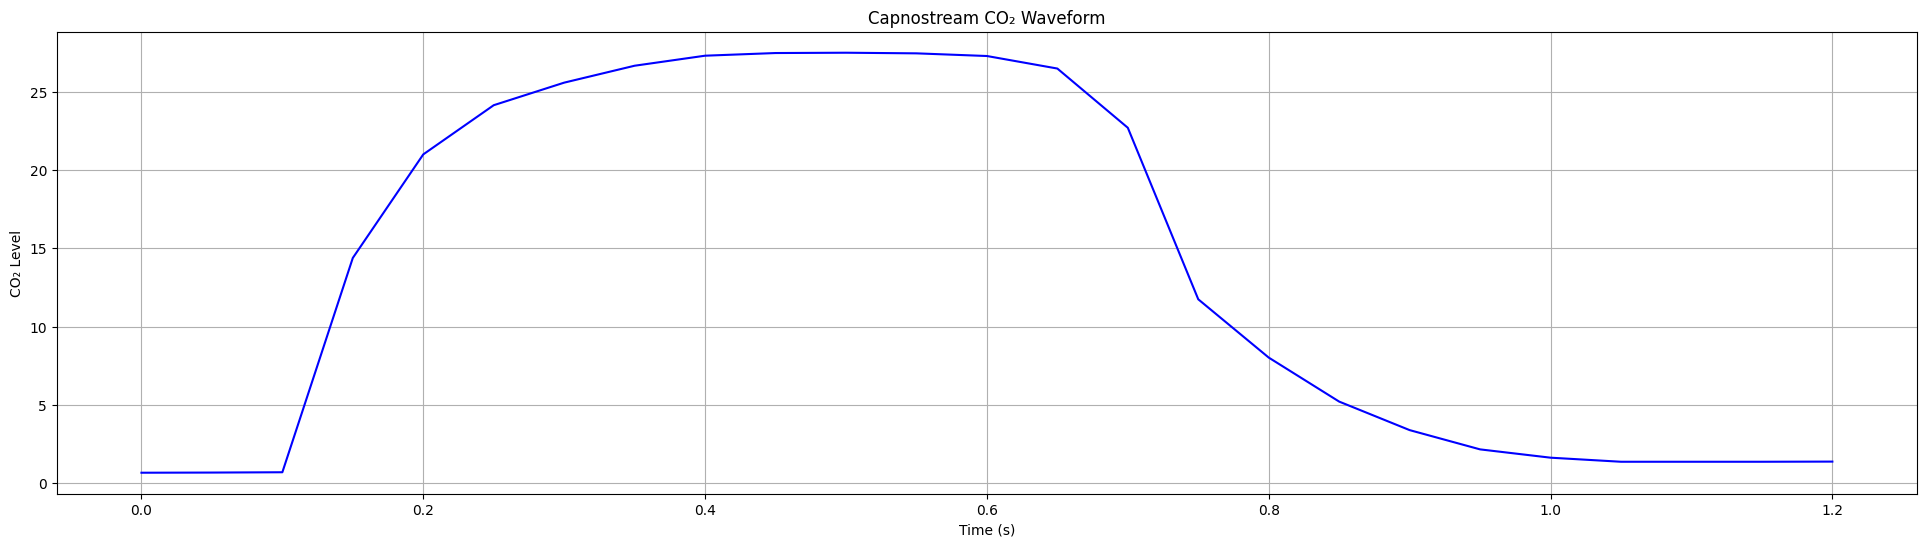

Augmentation type: scale


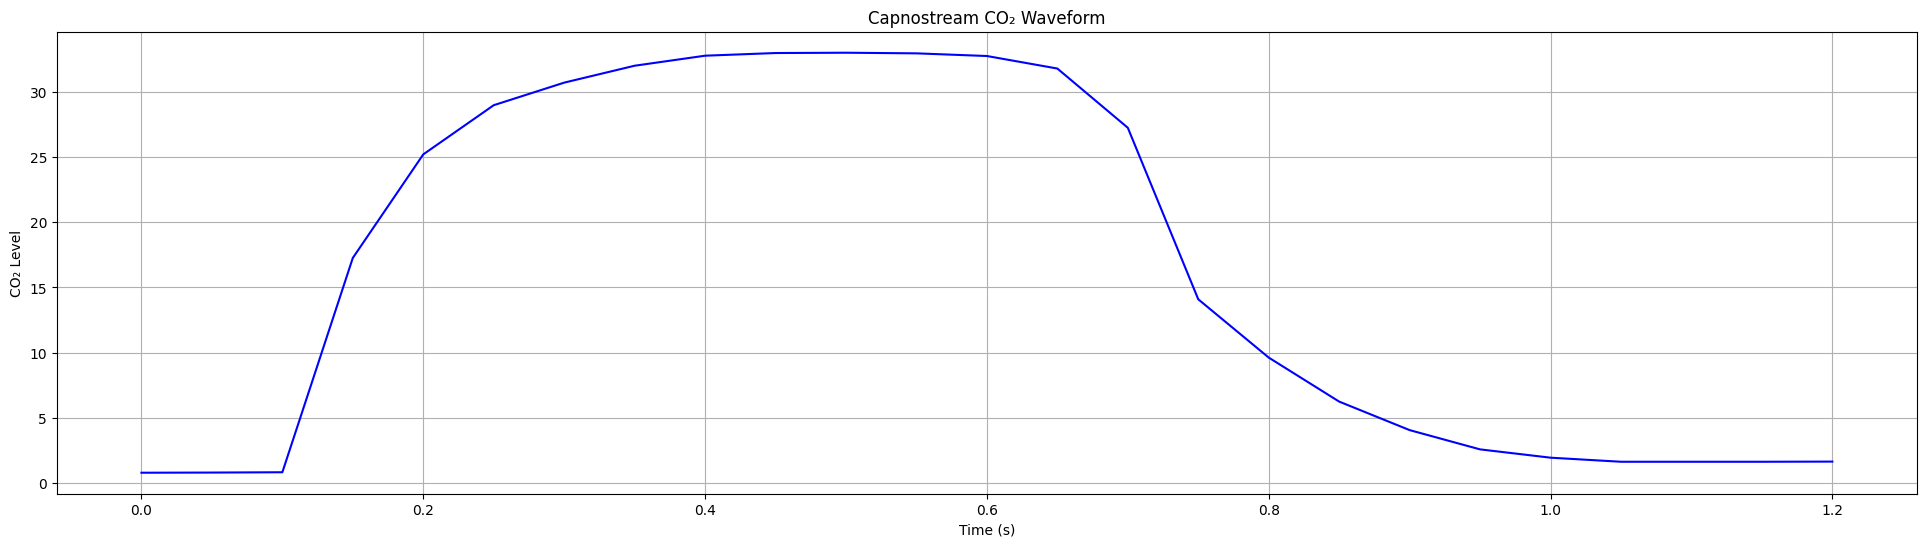

Augmentation type: roll


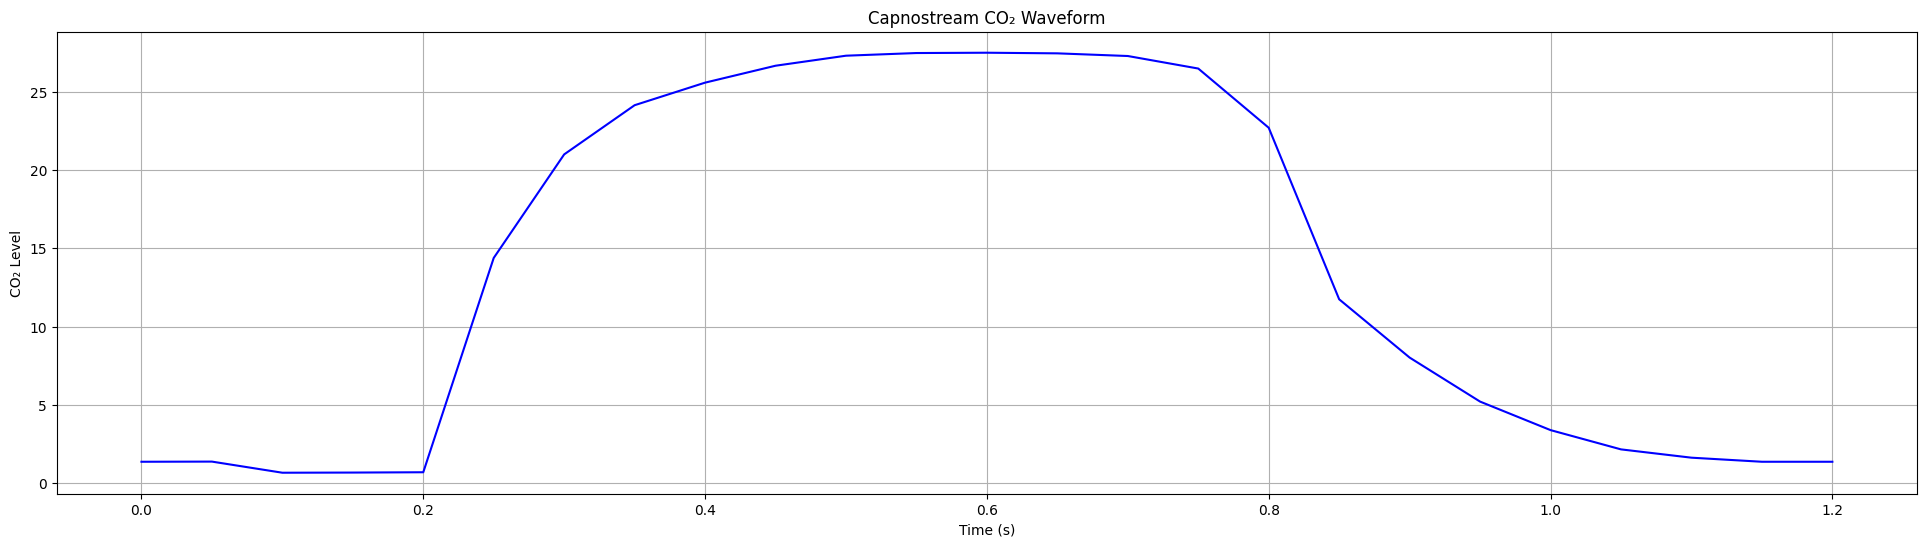

Augmentation type: noise


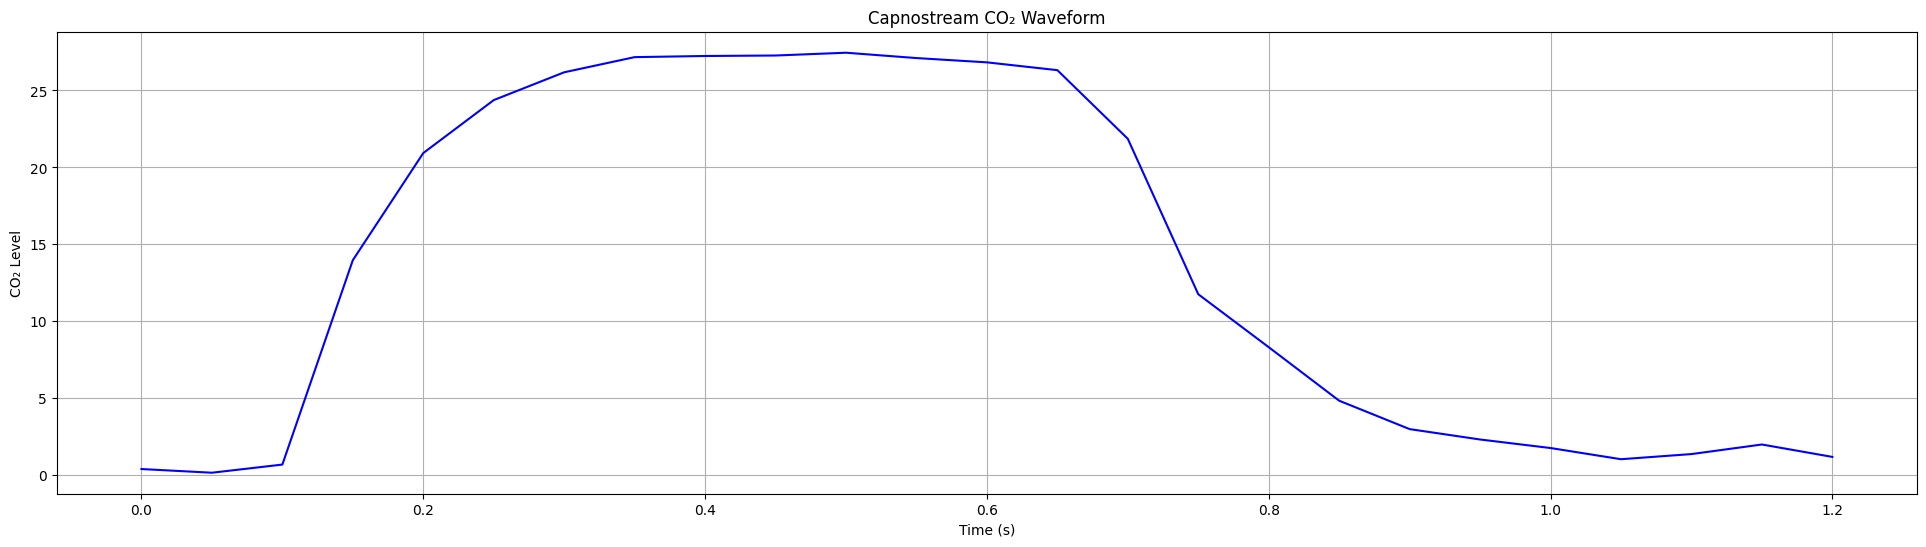

Augmentation type: stretch-wide


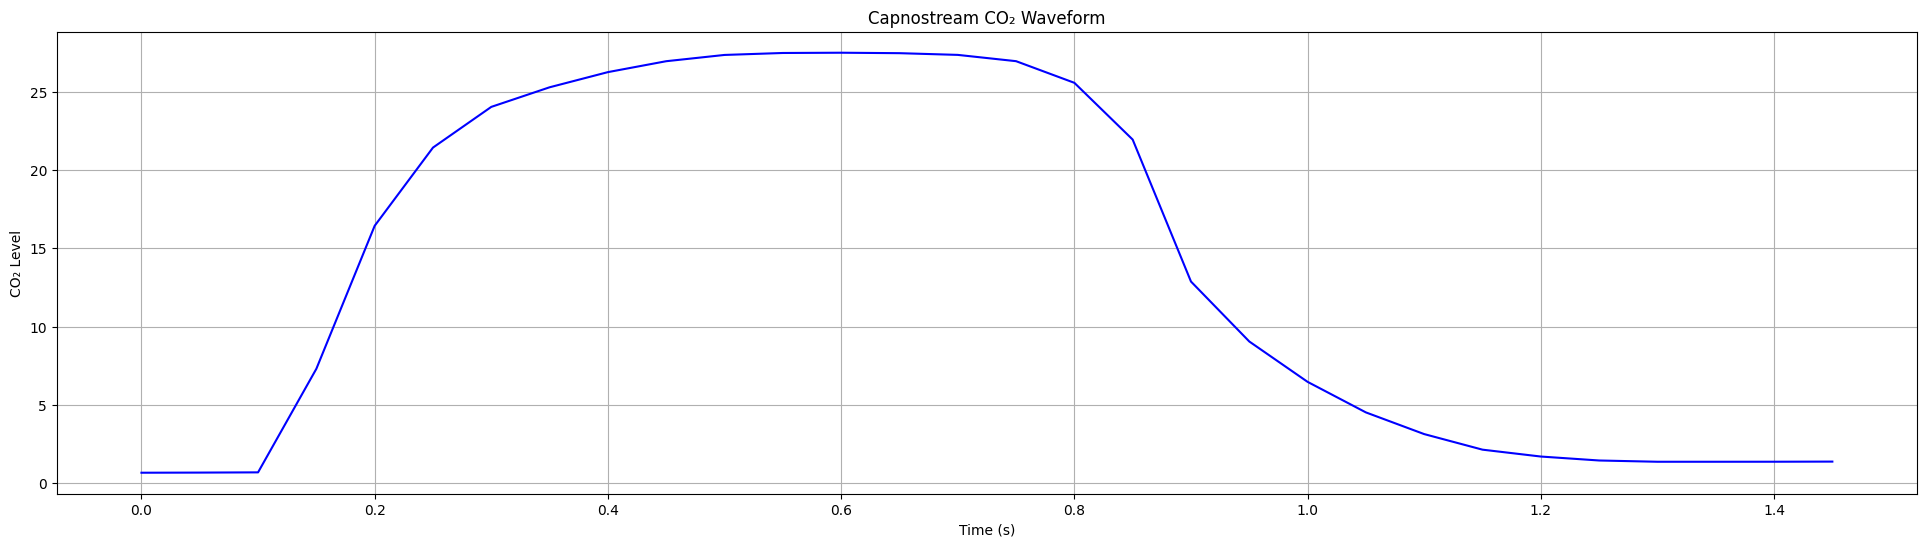

Augmentation type: stretch-narrow


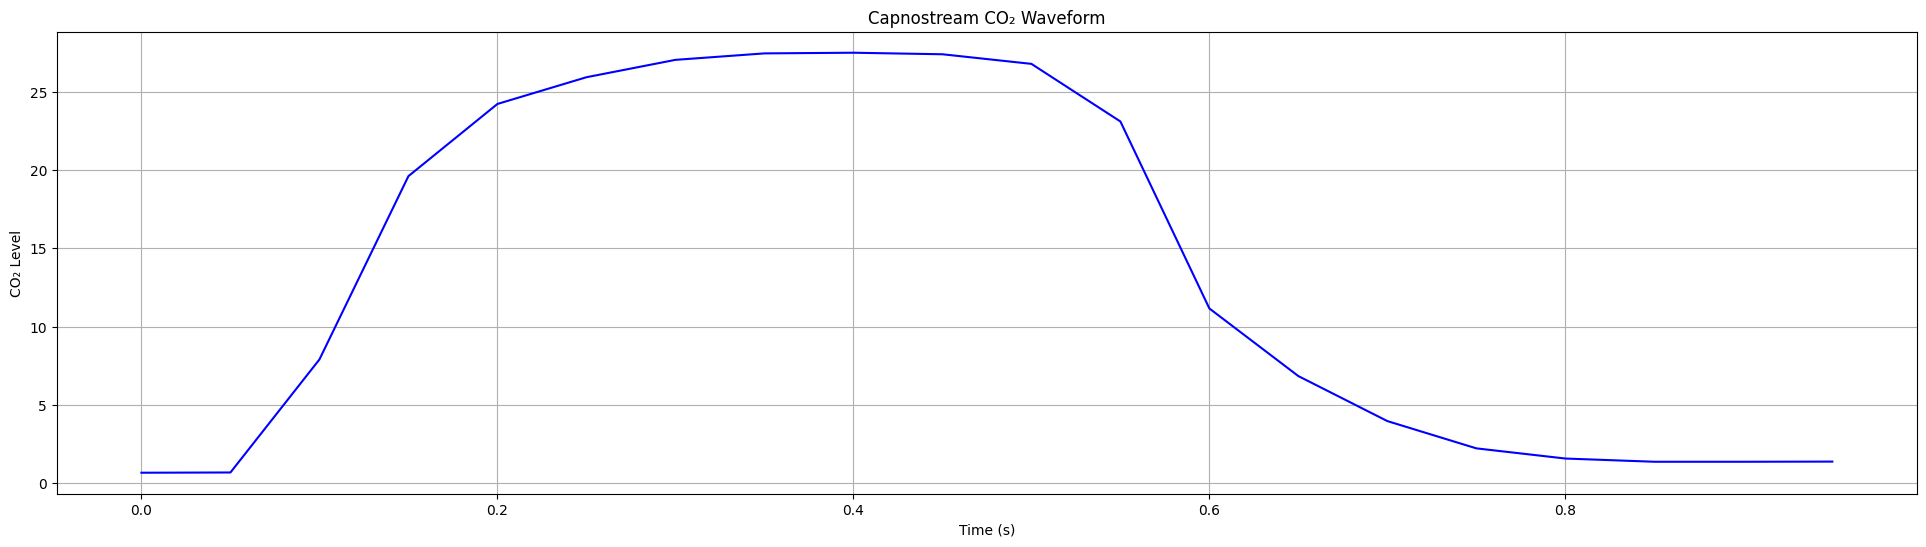

Augmentation type: all


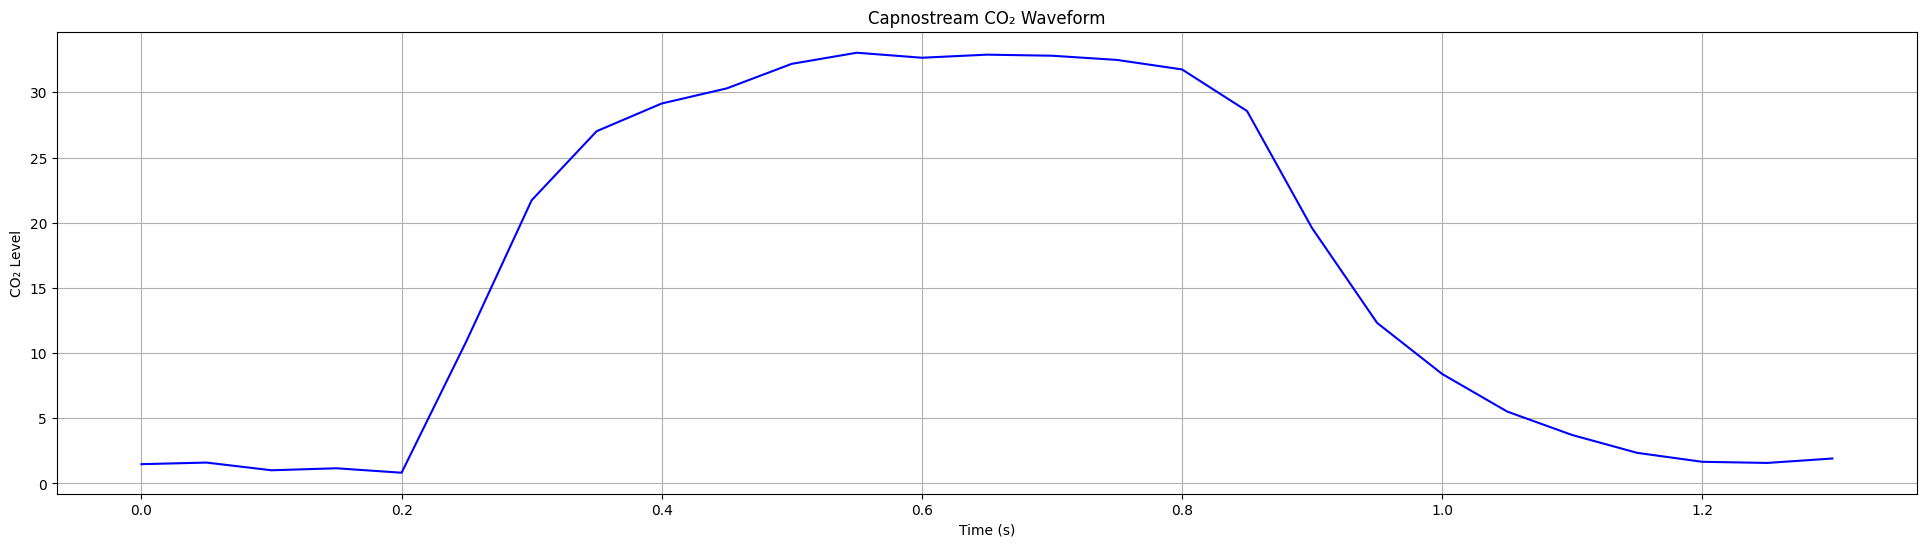

In [5]:
from data.prepare import augmentation

signals = [signal[start:end] for start, end in unit_markers]
print(f"Extracted {len(signals)} unit signals.")

raw_signal = signals[0]

augmented_signals = {
    "raw": raw_signal,
    "scale": augmentation.scale(raw_signal, scale_factor=1.2),
    "roll": augmentation.roll(raw_signal, roll_amount=2),
    "noise": augmentation.noise(raw_signal, noise_level=0.4),
    "stretch-wide": augmentation.stretch(raw_signal, stretch_factor=1.2),
    "stretch-narrow": augmentation.stretch(raw_signal, stretch_factor=0.8),
    "all": augmentation.stretch(augmentation.noise(augmentation.scale(augmentation.roll(raw_signal, roll_amount=2), scale_factor=1.2), noise_level=0.4), stretch_factor=1.1),
}

for aug_type, aug_signal in augmented_signals.items():
    print(f"Augmentation type: {aug_type}")
    plotting.plot_capnostream_waveform(data=aug_signal)
